# ESM2 Enzyme Classification — Clean Pipeline

End-to-end 7-class enzyme classification using **ESM2** (1280-dim) pooled embeddings.

## What this notebook does
- Loads the enzyme label CSV and builds clean 7-class labels (one unambiguous EC class per protein).
- Loads precomputed ESM2 embeddings (max pool and attention pool, 1280-dim).
- Trains and compares Logistic Regression and MLP classifiers.
- Reports Accuracy, Macro F1, Weighted F1, per-class metrics, and normalised confusion matrices.
- Generates PCA + t-SNE + UMAP embedding visualisations.
- Saves all plots, summary tables, and a self-contained HTML interpretation report to `results_enzyme_ESM2/`.
- Includes active-site 15-mer window analysis using per-residue ESM2 embeddings.

In [1]:
import base64
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import umap as umap_lib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results_enzyme_ESM2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Locate enzyme CSV (one directory up from this notebook)
ENZYME_CSV = (PROJECT_DIR / ".." / "all_uniref_enz_label_clean_isoform_removed.csv").resolve()

# Locate ESM2 pooled embeddings
candidate_embed_files = [
    Path("/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz"),
    Path("/home/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz"),
]
EMBED_FILE = next((p for p in candidate_embed_files if p.exists()), candidate_embed_files[0])

print(f"Project directory : {PROJECT_DIR}")
print(f"Results directory : {RESULTS_DIR}")
print(f"Enzyme CSV        : {ENZYME_CSV}  (exists: {ENZYME_CSV.exists()})")
print(f"Embedding file    : {EMBED_FILE}  (exists: {EMBED_FILE.exists()})")

Project directory : /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification
Results directory : /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2
Enzyme CSV        : /home/saishyam/Protein_dynamics/Enzyme_classification/all_uniref_enz_label_clean_isoform_removed.csv  (exists: True)
Embedding file    : /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz  (exists: True)


In [3]:
EC_CLASSES = {"oxidoreductase", "transferase", "hydrolase", "lyase", "isomerase", "ligase", "translocase"}

raw_df = pd.read_csv(ENZYME_CSV, low_memory=False)
print(f"Loaded {len(raw_df):,} rows from CSV")


def extract_single_ec(ec_text):
    """Return the single EC class name if exactly one known class is present, else None."""
    if pd.isna(ec_text):
        return None
    tokens  = {t.strip() for t in str(ec_text).lower().replace("/", ";").replace("|", ";").split(";") if t.strip()}
    matched = tokens.intersection(EC_CLASSES)
    return next(iter(matched)) if len(matched) == 1 else None


if "EC_classes_all" in raw_df.columns:
    raw_df["enzyme_label"] = raw_df["EC_classes_all"].apply(extract_single_ec)
elif "enzyme_label" in raw_df.columns:
    raw_df["enzyme_label"] = raw_df["enzyme_label"].astype(str).str.lower().str.strip()
else:
    raise KeyError("Expected 'EC_classes_all' or 'enzyme_label' column in input CSV")

enzyme_df = (
    raw_df[raw_df["enzyme_label"].isin(EC_CLASSES)]
    .loc[:, ["Entry", "Protein names", "Sequence", "enzyme_label"]]
    .rename(columns={"Entry": "protein_id", "Protein names": "protein_name"})
    .drop_duplicates(subset="protein_name", keep="first")
    .drop_duplicates(subset="protein_id",   keep="first")
    .reset_index(drop=True)
)

assert enzyme_df["protein_id"].is_unique
print(f"Proteins with definitive EC label: {len(enzyme_df):,}")
display(enzyme_df["enzyme_label"].value_counts().rename("count").to_frame())

Loaded 18,431 rows from CSV
Proteins with definitive EC label: 4,319


,count
enzyme_label,
transferase,1735
hydrolase,1598
oxidoreductase,521
isomerase,130
ligase,119
lyase,117
translocase,99


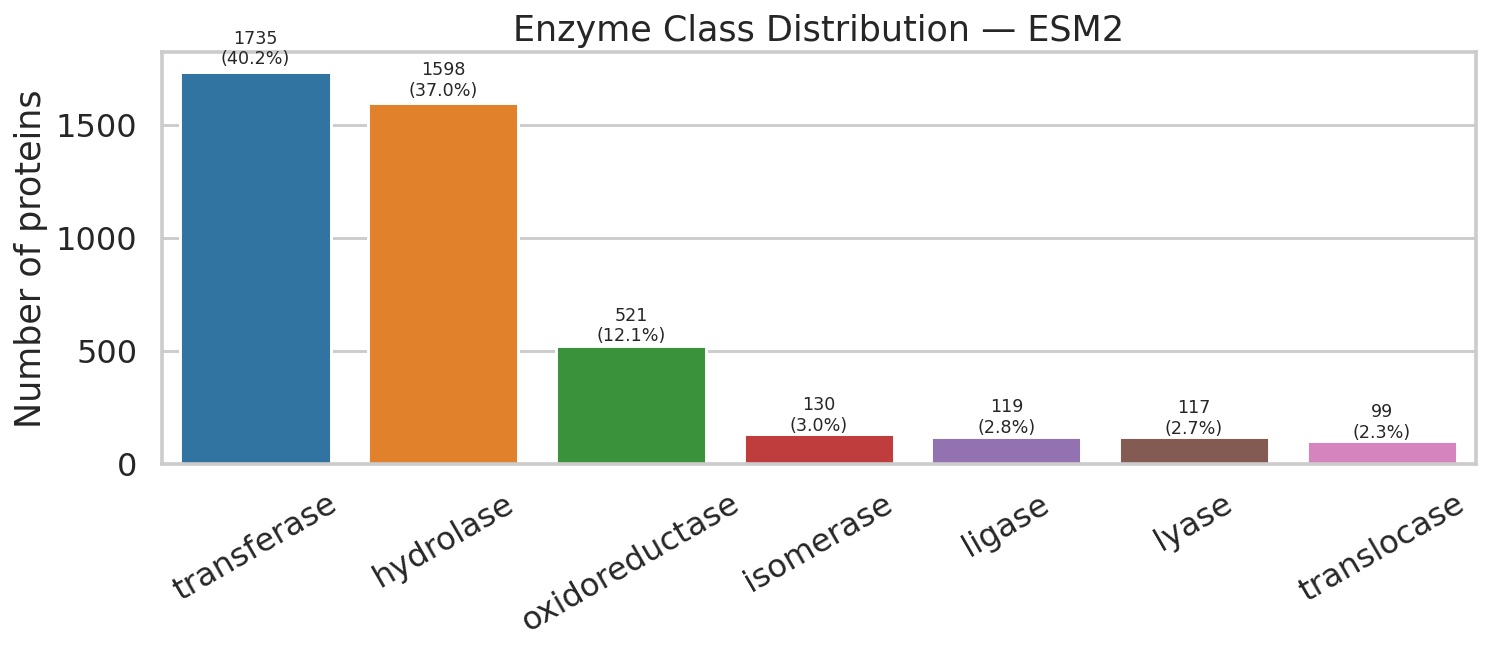

Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/class_distribution.png


In [4]:
vc  = enzyme_df["enzyme_label"].value_counts()
cdf = pd.DataFrame({"Class": vc.index, "Count": vc.values})
cdf["Fraction"] = cdf["Count"] / cdf["Count"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=cdf, x="Class", y="Count", hue="Class", legend=False, palette="tab10", ax=ax)
ax.set_title("Enzyme Class Distribution — ESM2")
ax.set_xlabel("")
ax.set_ylabel("Number of proteins")
ax.tick_params(axis="x", rotation=30)
for i, row in cdf.iterrows():
    ax.text(i, row["Count"] * 1.01,
            f"{int(row['Count'])}\n({row['Fraction']:.1%})",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
class_dist_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(class_dist_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {class_dist_path}")

In [5]:
print(f"Loading ESM2 embeddings from: {EMBED_FILE}")
t0        = time.perf_counter()
cache     = np.load(EMBED_FILE, allow_pickle=True)
max_pool  = cache["max"].item()   # dict: protein_id -> (1280,) ndarray
attn_pool = cache["attn"].item()  # dict: protein_id -> (1280,) ndarray
print(f"Loaded in {time.perf_counter()-t0:.1f}s")

X_max_list, X_attn_list, y_list = [], [], []
missing = 0
for pid, label in zip(enzyme_df["protein_id"], enzyme_df["enzyme_label"]):
    vm = max_pool.get(pid)
    va = attn_pool.get(pid)
    if vm is not None and va is not None:
        X_max_list.append(vm)
        X_attn_list.append(va)
        y_list.append(label)
    else:
        missing += 1
if missing:
    print(f"Missing embeddings: {missing} proteins skipped")

X_max  = np.stack(X_max_list).astype(np.float32)
X_attn = np.stack(X_attn_list).astype(np.float32)
y_str  = np.array(y_list)

assert X_max.shape[1] == 1280, f"Expected 1280-dim ESM2 embeddings, got {X_max.shape[1]}"
print(f"Max-pool  : {X_max.shape}")
print(f"Attn-pool : {X_attn.shape}")

le          = LabelEncoder()
y_enc       = le.fit_transform(y_str)
class_names = le.classes_
n_classes   = len(class_names)
print(f"Classes ({n_classes}): {class_names.tolist()}")

Loading ESM2 embeddings from: /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz
Loaded in 1.7s
Missing embeddings: 8 proteins skipped
Max-pool  : (4311, 1280)
Attn-pool : (4311, 1280)
Classes (7): ['hydrolase', 'isomerase', 'ligase', 'lyase', 'oxidoreductase', 'transferase', 'translocase']


In [17]:
def make_split(X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    return Xtr, Xte, ytr, yte


def evaluate(y_true, y_pred):
    prec, rec, f1_pc, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    return {
        "accuracy":            accuracy_score(y_true, y_pred),
        "macro_f1":            f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "weighted_f1":         f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "per_class_precision": prec,
        "per_class_recall":    rec,
        "per_class_f1":        f1_pc,
    }


split_data = {
    "max":  make_split(X_max,  y_enc),
    "attn": make_split(X_attn, y_enc),
}

results    = []
pred_store = {}

t0 = time.perf_counter()
for pname, (Xtr, Xte, ytr, yte) in split_data.items():
    clf = LogisticRegression(
        max_iter=5000, class_weight="balanced",
        solver="lbfgs", random_state=SEED,
    )
    clf.fit(Xtr, ytr)
    yp = clf.predict(Xte)
    m  = evaluate(yte, yp)
    results.append({
        "model": "logistic_regression", "pooling": pname,
        "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        "weighted_f1": m["weighted_f1"], "n_test": len(yte),
    })
    pred_store[("logistic_regression", pname)] = {
        "y_true": yte, "y_pred": yp, "metrics": m
    }
print(f"Logistic regression complete in {time.perf_counter()-t0:.1f}s")

Logistic regression complete in 168.5s


In [18]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(Xtr, ytr, Xte, n_cls, epochs=30, batch_size=64, lr=1e-3):
    loader  = DataLoader(
        TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
        batch_size=batch_size, shuffle=True,
    )
    counts  = np.bincount(ytr, minlength=n_cls)
    weights = torch.tensor(
        counts.sum() / np.maximum(counts, 1), dtype=torch.float32
    ).to(device)
    model = MLP(Xtr.shape[1], n_cls).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.CrossEntropyLoss(weight=weights)
    losses = []
    model.train()
    for _ in range(epochs):
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item()
        losses.append(running / len(loader))
    model.eval()
    with torch.no_grad():
        yp = torch.argmax(
            model(torch.from_numpy(Xte).to(device)), dim=1
        ).cpu().numpy()
    return yp, losses


training_loss = {}
t0 = time.perf_counter()
for pname, (Xtr, Xte, ytr, yte) in split_data.items():
    yp, losses = train_mlp(Xtr, ytr, Xte, n_classes)
    m = evaluate(yte, yp)
    results.append({
        "model": "mlp", "pooling": pname,
        "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        "weighted_f1": m["weighted_f1"], "n_test": len(yte),
    })
    pred_store[("mlp", pname)] = {
        "y_true": yte, "y_pred": yp, "metrics": m
    }
    training_loss[pname] = losses
print(f"MLP training complete in {time.perf_counter()-t0:.1f}s")

MLP training complete in 4.5s


In [19]:
results_df = (
    pd.DataFrame(results)[["model", "pooling", "accuracy", "macro_f1", "weighted_f1", "n_test"]]
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

csv_path = RESULTS_DIR / "summary_metrics.csv"
md_path  = RESULTS_DIR / "summary_metrics.md"
results_df.to_csv(csv_path, index=False)

fmt_cols  = {"accuracy", "macro_f1", "weighted_f1"}
def _fmt(col, v):
    return f"{v:.4f}" if col in fmt_cols else str(v)
header    = "| " + " | ".join(results_df.columns) + " |"
separator = "|" + "|".join(["---"] * len(results_df.columns)) + "|"
rows_md   = [
    "| " + " | ".join(_fmt(c, v) for c, v in zip(results_df.columns, row)) + " |"
    for row in results_df.to_numpy()
]
md_path.write_text("\n".join([header, separator] + rows_md))

display(results_df.style.format({
    "accuracy":    "{:.4f}",
    "macro_f1":    "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
print(f"Saved: {csv_path}")
print(f"Saved: {md_path}")

,model,pooling,accuracy,macro_f1,weighted_f1,n_test
0,mlp,attn,0.8841,0.8029,0.8832,863
1,logistic_regression,max,0.8366,0.7633,0.8368,863
2,logistic_regression,attn,0.8308,0.7396,0.8422,863
3,mlp,max,0.4021,0.0819,0.2306,863


Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/summary_metrics.csv
Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/summary_metrics.md


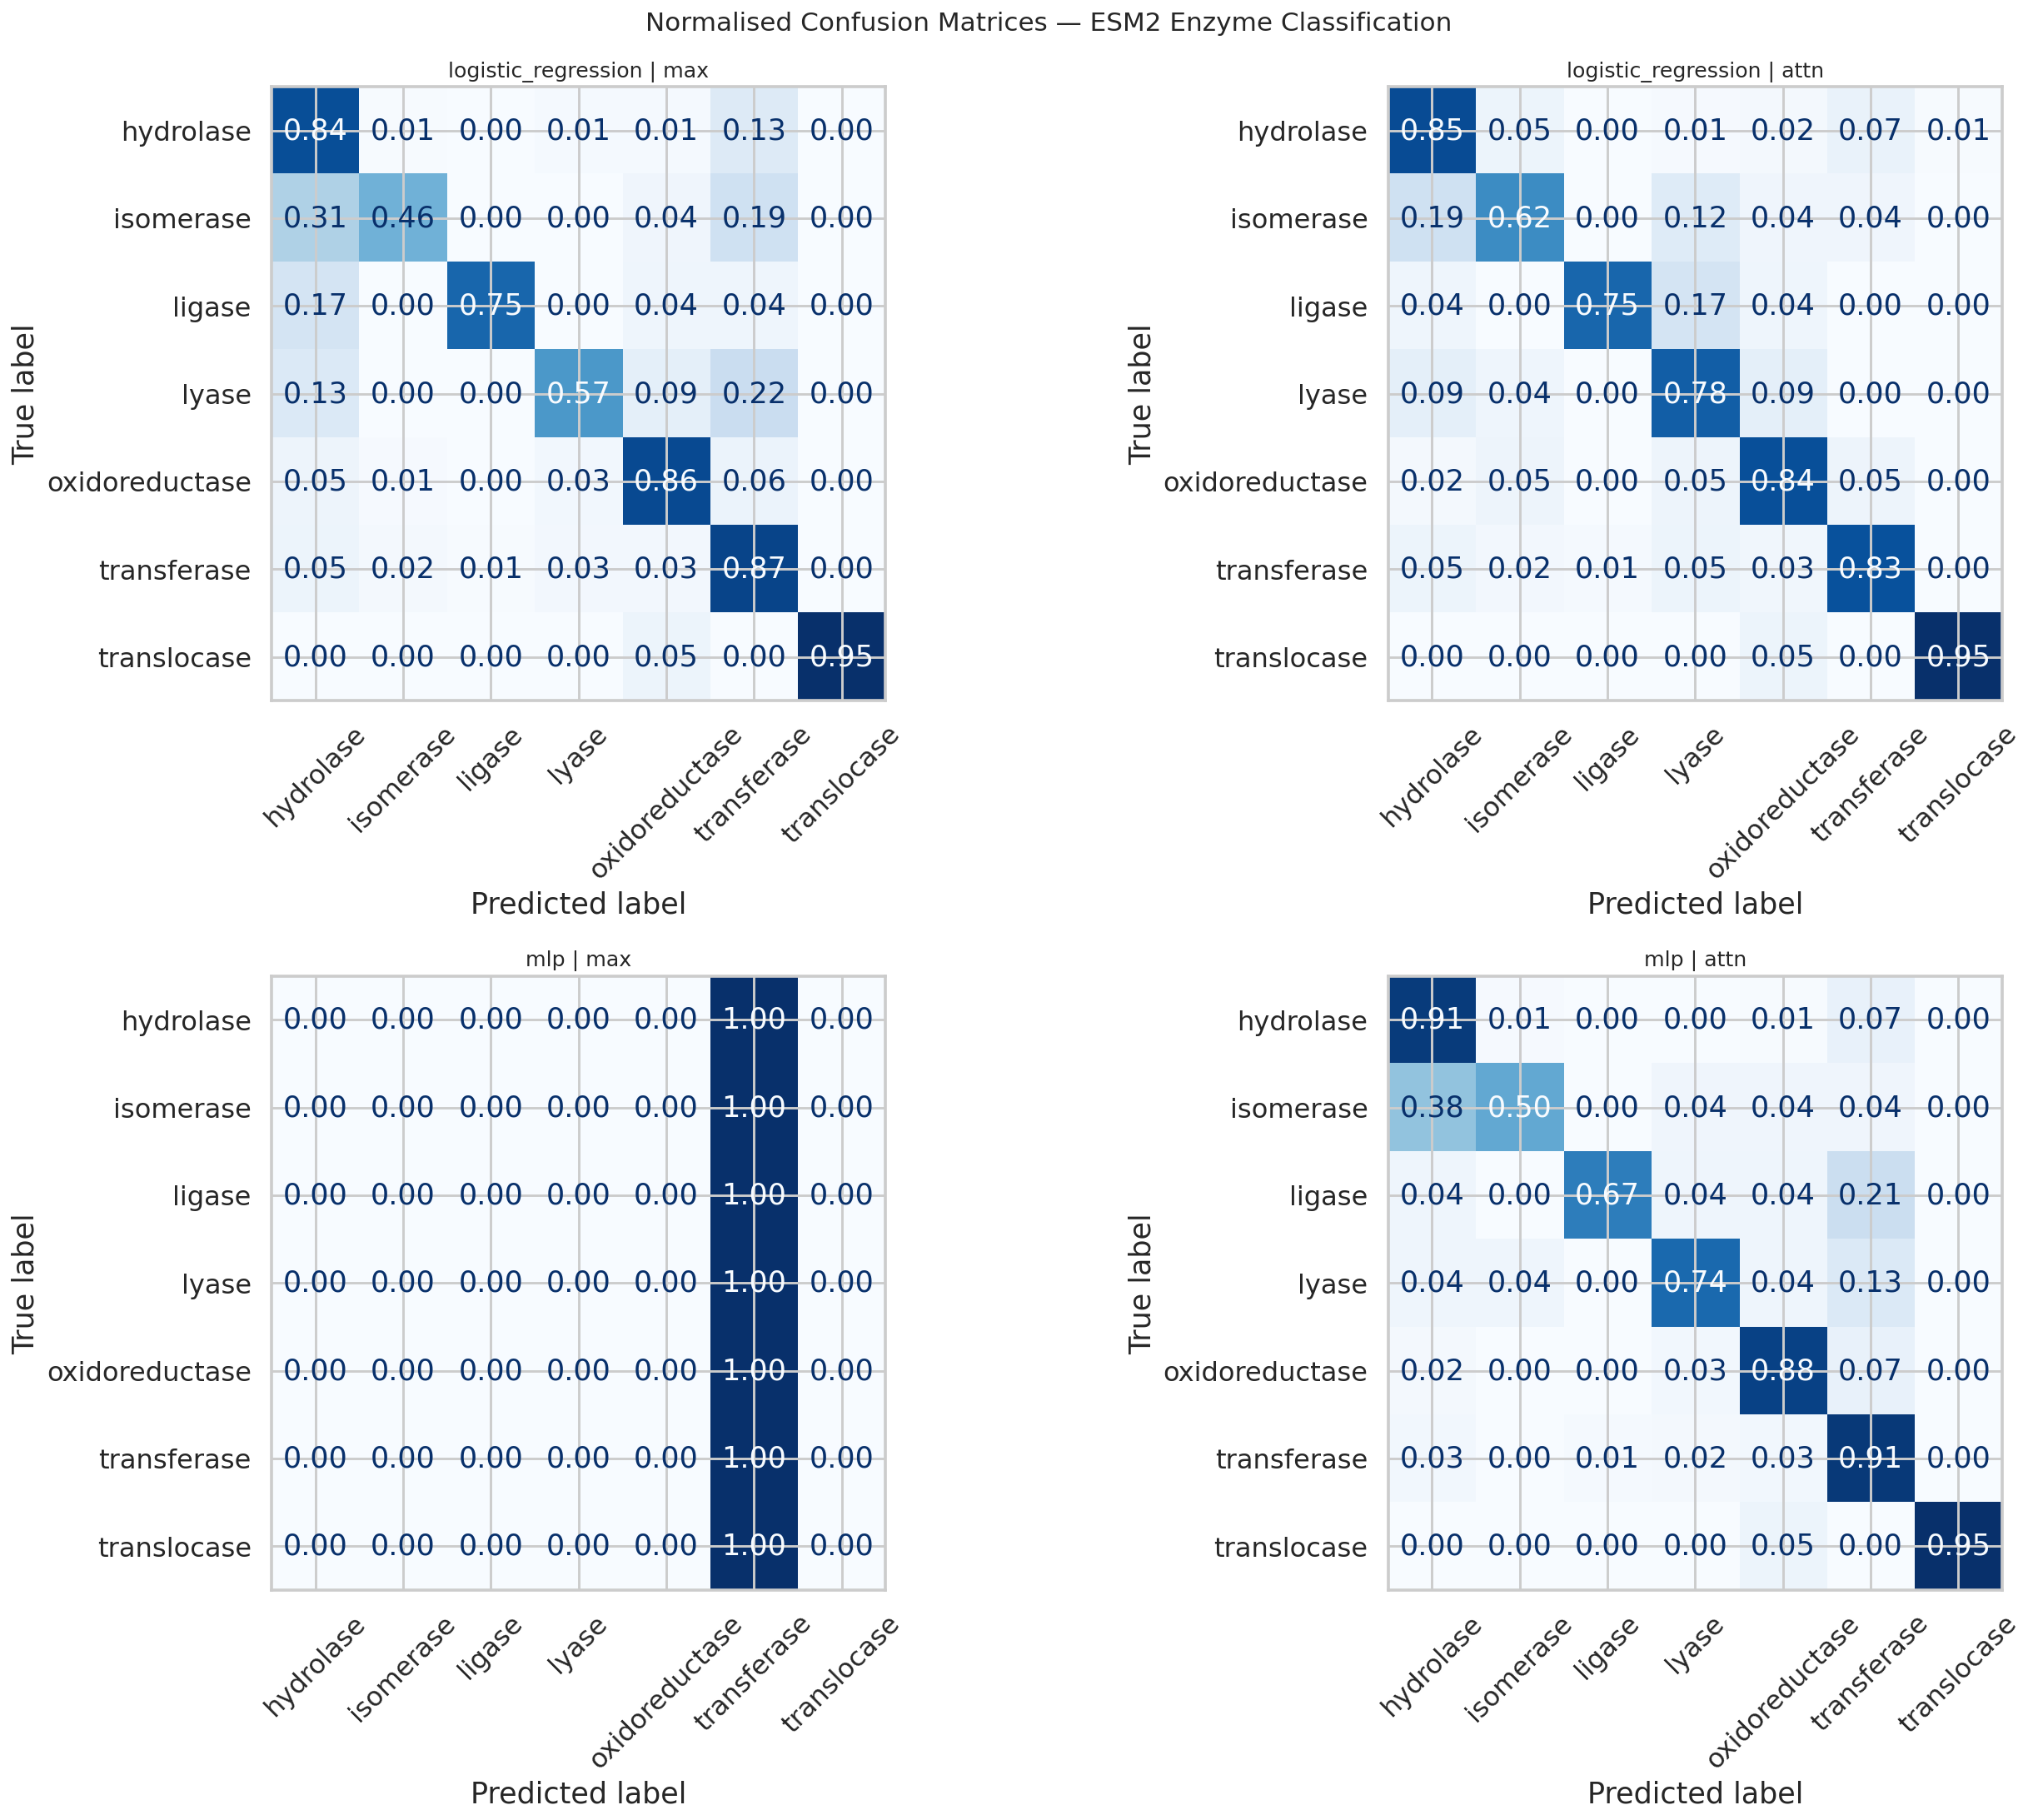

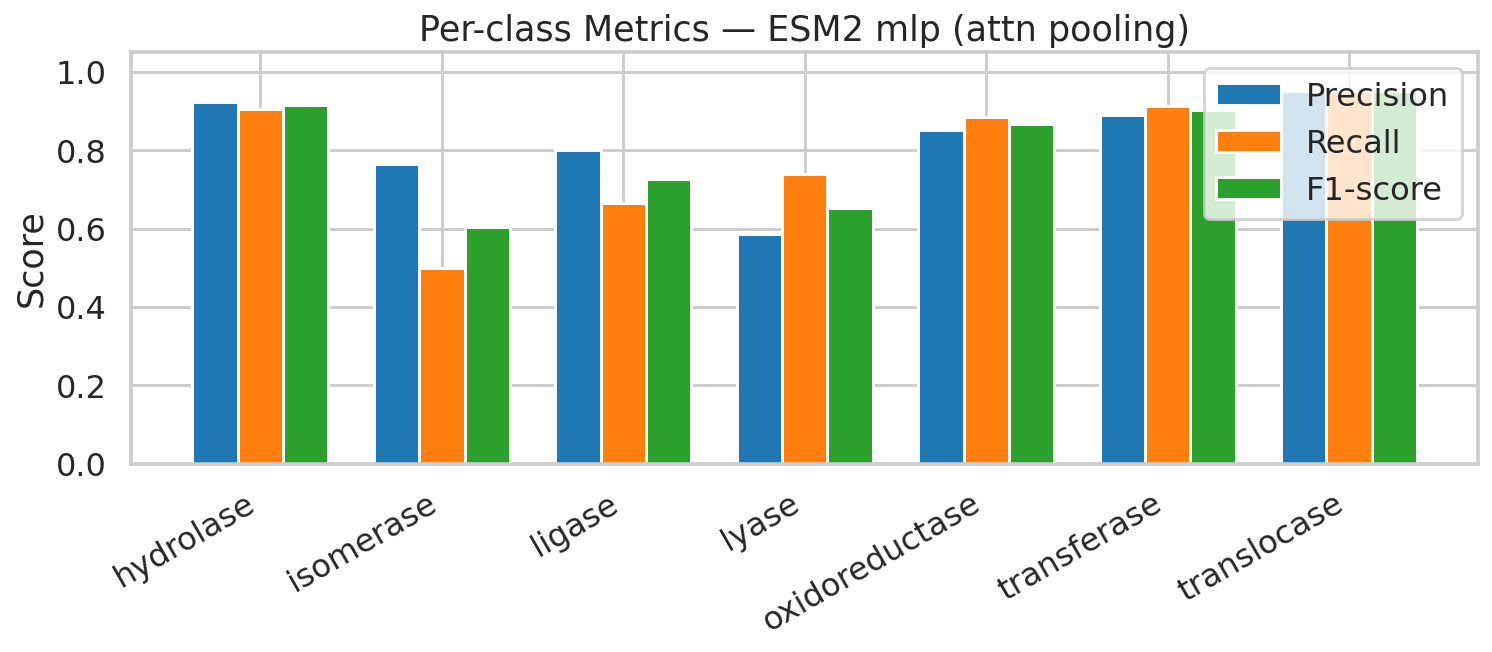

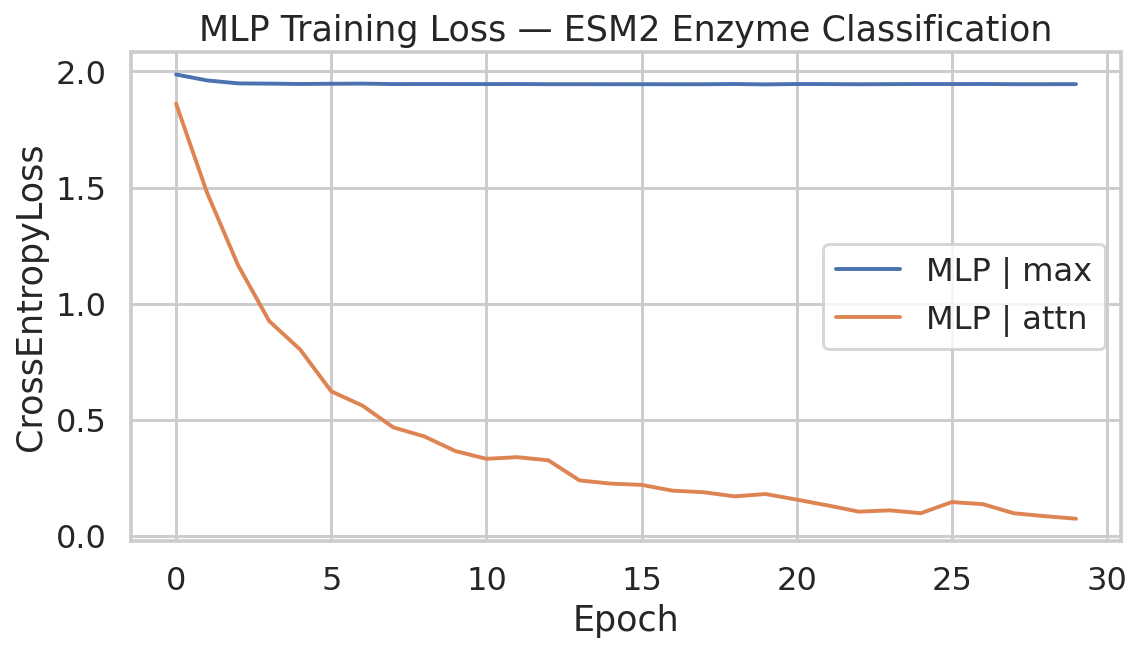

Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/confusion_matrices.png
Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/per_class_metrics.png
Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/mlp_training_loss.png


In [20]:
best_row   = results_df.iloc[0]
keys_order = [
    ("logistic_regression", "max"),
    ("logistic_regression", "attn"),
    ("mlp", "max"),
    ("mlp", "attn"),
]

# ---- Normalised confusion matrices (2x2 grid) ----
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
for ax, key in zip(axes.ravel(), keys_order):
    d  = pred_store[key]
    cm = confusion_matrix(d["y_true"], d["y_pred"], normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False
    )
    ax.set_title(f"{key[0]} | {key[1]}", fontsize=13)
plt.suptitle("Normalised Confusion Matrices — ESM2 Enzyme Classification", fontsize=16)
plt.tight_layout()
cm_path = RESULTS_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- Per-class Precision / Recall / F1 (best model) ----
best_key = (best_row["model"], best_row["pooling"])
m_best   = pred_store[best_key]["metrics"]
x, width = np.arange(n_classes), 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, m_best["per_class_precision"], width, label="Precision", color="#1f77b4")
ax.bar(x,         m_best["per_class_recall"],    width, label="Recall",    color="#ff7f0e")
ax.bar(x + width, m_best["per_class_f1"],        width, label="F1-score",  color="#2ca02c")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Per-class Metrics — ESM2 {best_key[0]} ({best_key[1]} pooling)")
ax.legend()
plt.tight_layout()
pc_path = RESULTS_DIR / "per_class_metrics.png"
plt.savefig(pc_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- MLP training loss ----
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(training_loss["max"],  label="MLP | max",  linewidth=2)
ax.plot(training_loss["attn"], label="MLP | attn", linewidth=2)
ax.set_title("MLP Training Loss — ESM2 Enzyme Classification")
ax.set_xlabel("Epoch")
ax.set_ylabel("CrossEntropyLoss")
ax.legend()
plt.tight_layout()
loss_path = RESULTS_DIR / "mlp_training_loss.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {cm_path}")
print(f"Saved: {pc_path}")
print(f"Saved: {loss_path}")

Visualising full set of 4311 points
t-SNE complete in 24.7s


/home/saishyam/esm2_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete in 6.4s


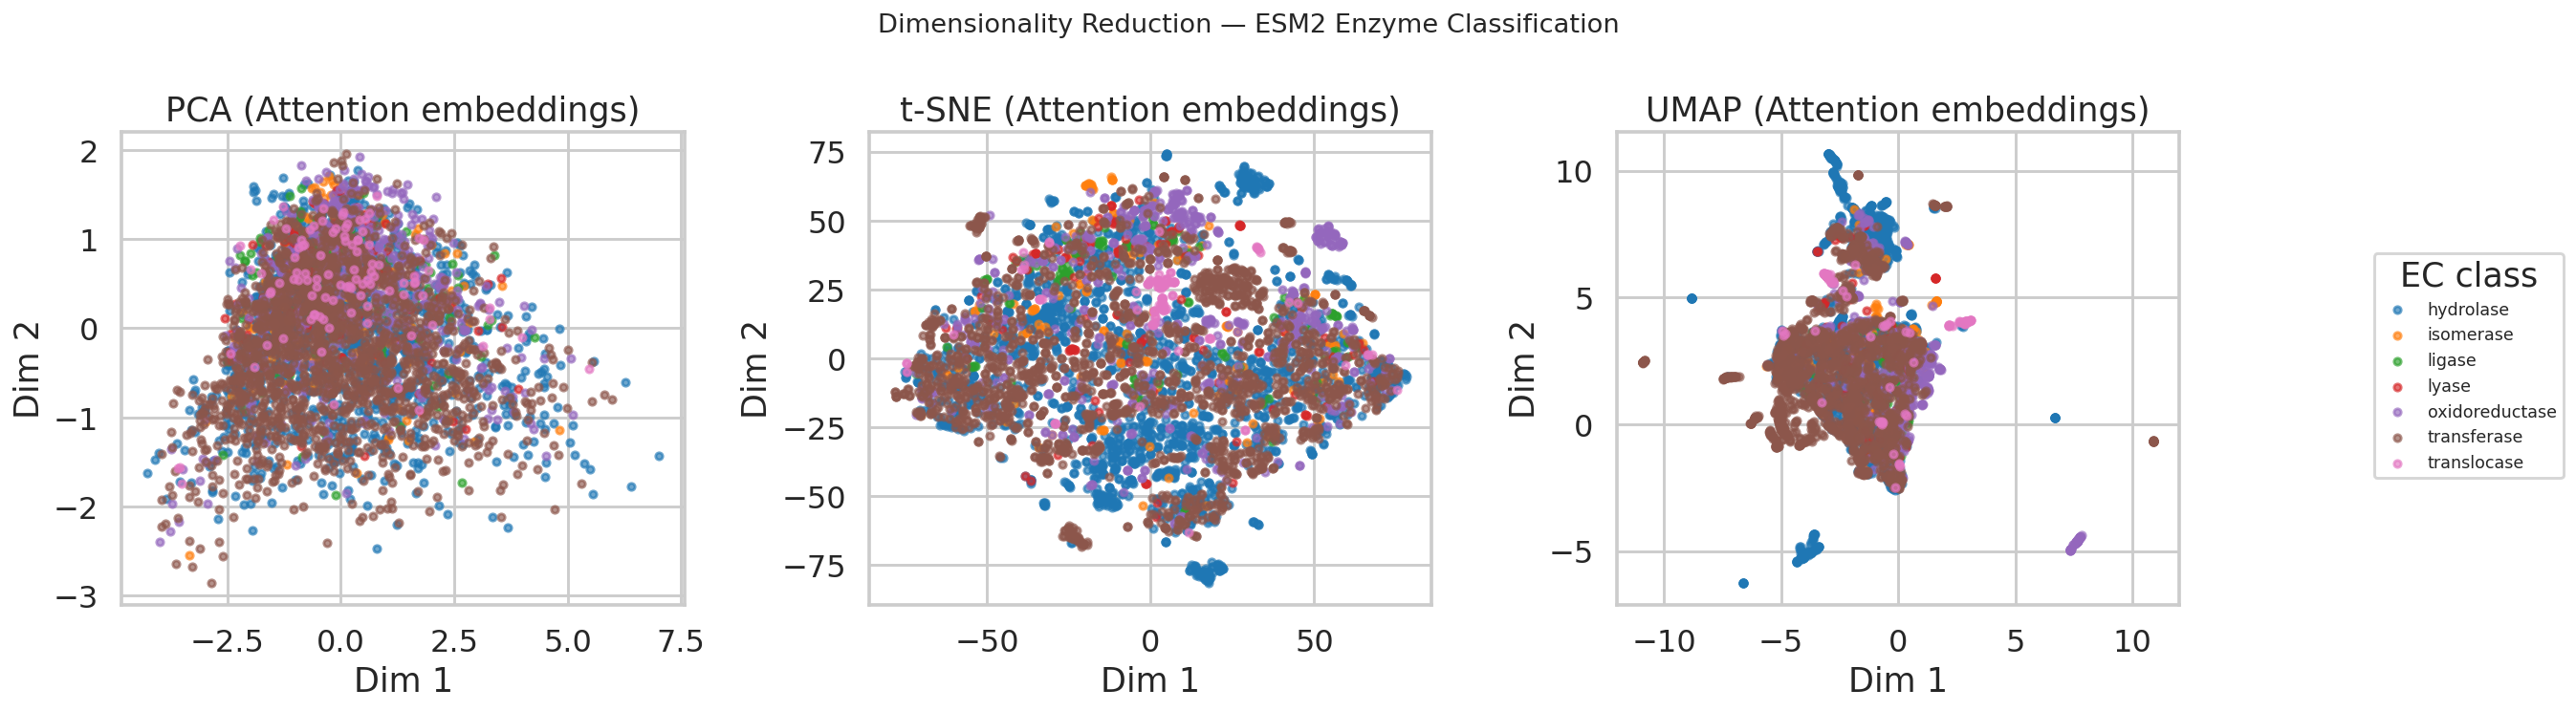

Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/embedding_projection_pca_tsne_umap.png


In [21]:
MAX_VIS = 5000
if len(X_attn) > MAX_VIS:
    rng   = np.random.default_rng(SEED)
    idx   = rng.choice(len(X_attn), size=MAX_VIS, replace=False)
    X_vis = X_attn[idx]
    y_vis = y_enc[idx]
    print(f"Visualising random subset of {MAX_VIS} points")
else:
    X_vis, y_vis = X_attn, y_enc
    print(f"Visualising full set of {len(X_vis)} points")

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)

t0 = time.perf_counter()
tsne_2d = TSNE(
    n_components=2, init="pca", learning_rate="auto",
    perplexity=30, random_state=SEED
).fit_transform(X_vis)
print(f"t-SNE complete in {time.perf_counter()-t0:.1f}s")

t0 = time.perf_counter()
umap_2d = umap_lib.UMAP(
    n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED
).fit_transform(X_vis)
print(f"UMAP complete in {time.perf_counter()-t0:.1f}s")

cmap_c = mpl.colormaps.get_cmap("tab10")
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, (title, emb) in zip(axes, [
    ("PCA (Attention embeddings)",   pca_2d),
    ("t-SNE (Attention embeddings)", tsne_2d),
    ("UMAP (Attention embeddings)",  umap_2d),
]):
    for ci, cn in enumerate(class_names):
        mask = y_vis == ci
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   s=14, alpha=0.65, color=cmap_c(ci), label=cn, zorder=2)
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="center right",
           bbox_to_anchor=(1.02, 0.5), title="EC class", fontsize=9)
plt.suptitle("Dimensionality Reduction — ESM2 Enzyme Classification", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 1])
emb_path = RESULTS_DIR / "embedding_projection_pca_tsne_umap.png"
plt.savefig(emb_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {emb_path}")

In [22]:
best_row = results_df.iloc[0]
summary_lines = [
    "ANALYSIS SUMMARY — ESM2 Enzyme Classification",
    "==============================================",
    "",
    "── Full-protein (pooled embeddings) ──────────────────",
    f"  Best model by Macro F1: {best_row['model']} + {best_row['pooling']}",
    f"  Accuracy    : {best_row['accuracy']:.4f}",
    f"  Macro F1    : {best_row['macro_f1']:.4f}",
    f"  Weighted F1 : {best_row['weighted_f1']:.4f}",
    "",
    "  All full-protein configs (sorted by Macro F1):",
]
for _, r in results_df.iterrows():
    summary_lines.append(
        f"    {r['model']:25s} | {r['pooling']:4s} | "
        f"Acc={r['accuracy']:.4f}  MacroF1={r['macro_f1']:.4f}  WtdF1={r['weighted_f1']:.4f}"
    )

summary_lines += [
    "",
    "── Active-site 15-mer window ─────────────────────────",
    "  (see active_site_window_* plots; stats appended below after window cell runs)",
    "",
    "Interpretation:",
    "- Macro F1 is the primary metric (equal weight across all 7 EC classes).",
    "- ESM2 uses 1280-dim embeddings.",
    "- 7-class EC classification: oxidoreductase, transferase, hydrolase,",
    "  lyase, isomerase, ligase, translocase.",
    "- Confusion matrices are row-normalised (recall per class).",
]

analysis_path = RESULTS_DIR / "analysis_summary.txt"
analysis_path.write_text("\n".join(summary_lines))
print("\n".join(summary_lines))
print(f"\nSaved: {analysis_path}")


ANALYSIS SUMMARY — ESM2 Enzyme Classification

── Full-protein (pooled embeddings) ──────────────────
  Best model by Macro F1: mlp + attn
  Accuracy    : 0.8841
  Macro F1    : 0.8029
  Weighted F1 : 0.8832

  All full-protein configs (sorted by Macro F1):
    mlp                       | attn | Acc=0.8841  MacroF1=0.8029  WtdF1=0.8832
    logistic_regression       | max  | Acc=0.8366  MacroF1=0.7633  WtdF1=0.8368
    logistic_regression       | attn | Acc=0.8308  MacroF1=0.7396  WtdF1=0.8422
    mlp                       | max  | Acc=0.4021  MacroF1=0.0819  WtdF1=0.2306

── Active-site 15-mer window ─────────────────────────
  (see active_site_window_* plots; stats appended below after window cell runs)

Interpretation:
- Macro F1 is the primary metric (equal weight across all 7 EC classes).
- ESM2 uses 1280-dim embeddings.
- 7-class EC classification: oxidoreductase, transferase, hydrolase,
  lyase, isomerase, ligase, translocase.
- Confusion matrices are row-normalised (recall per c

In [23]:
import re
from typing import Optional

# ============================================================
# Active-site 15-mer window dataset
# ESM2 per-residue embeddings  (.pt files, shape L×1280)
# ============================================================

RESIDUE_DIR  = Path("/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache")

WINDOW       = 15
HALF         = WINDOW // 2
NEG_PER_PROT = 3   # non-active windows per protein (labelled "non_catalytic")


def load_residue_emb(pid: str) -> Optional[np.ndarray]:
    path = RESIDUE_DIR / f"{pid}.pt"
    if not path.exists():
        return None
    emb = torch.load(path, map_location="cpu")
    E   = emb if isinstance(emb, torch.Tensor) else emb["embeddings"]
    arr = E.cpu().numpy()          # (L, 1280)
    assert arr.ndim == 2
    return arr


def extract_window(E: np.ndarray, center_1based: int) -> Optional[np.ndarray]:
    c = int(center_1based) - 1     # 0-based
    s, e = c - HALF, c + HALF + 1
    if s < 0 or e > E.shape[0]:
        return None
    return E[s:e].mean(axis=0)     # mean-pool → (1280,)


def sample_neg_windows(E: np.ndarray, center_1based: int, k: int = 3) -> list:
    c = int(center_1based) - 1
    forbidden = set(range(c - HALF, c + HALF + 1))
    valid = [i for i in range(HALF, E.shape[0] - HALF) if i not in forbidden]
    chosen = random.sample(valid, k=min(k, len(valid))) if valid else []
    return [E[i - HALF : i + HALF + 1].mean(axis=0) for i in chosen]


# ---- Parse active site positions from CSV ----
def first_active_site(text) -> Optional[int]:
    if pd.isna(text):
        return None
    positions = re.findall(r"\d+", str(text))
    return int(positions[0]) if positions else None


raw_df["active_site_pos"] = raw_df["Active site"].apply(first_active_site)

act_df = (
    raw_df[
        raw_df["enzyme_label"].isin(EC_CLASSES) &
        raw_df["active_site_pos"].notna()
    ]
    .loc[:, ["Entry", "enzyme_label", "active_site_pos"]]
    .rename(columns={"Entry": "protein_id"})
    .drop_duplicates(subset="protein_id", keep="first")
    .reset_index(drop=True)
)
print(f"Proteins with active site annotation: {len(act_df):,}")
display(act_df["enzyme_label"].value_counts().rename("count").to_frame())

# ---- Build window feature matrix ----
X_win, y_win = [], []
skipped_win  = 0

t0 = time.perf_counter()
for _, row in act_df.iterrows():
    pid     = row["protein_id"]
    label   = row["enzyme_label"]
    act_pos = row["active_site_pos"]

    E = load_residue_emb(pid)
    if E is None:
        skipped_win += 1
        continue

    # Active site window
    w_act = extract_window(E, act_pos)
    if w_act is None:
        skipped_win += 1
        continue
    X_win.append(w_act);  y_win.append(label)

    # Non-active windows → labelled "non_catalytic"
    for w_neg in sample_neg_windows(E, act_pos, k=NEG_PER_PROT):
        X_win.append(w_neg);  y_win.append("non_catalytic")

X_win = np.vstack(X_win).astype(np.float32)
y_win = np.array(y_win)
print(f"Dataset built in {time.perf_counter()-t0:.1f}s — "
      f"{len(X_win):,} windows  ({skipped_win} proteins skipped)")
print(f"Window embedding dim: {X_win.shape[1]}")
display(pd.Series(y_win).value_counts().rename("count").to_frame())

Proteins with active site annotation: 2,120


,count
enzyme_label,
hydrolase,985
transferase,774
oxidoreductase,197
lyase,56
isomerase,49
translocase,36
ligase,23


/tmp/ipykernel_4024140/532342220.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb = torch.load(path, map_location="cpu")


Dataset built in 4.8s — 8,160 windows  (80 proteins skipped)
Window embedding dim: 1280


,count
non_catalytic,6120
hydrolase,957
transferase,729
oxidoreductase,195
lyase,56
isomerase,48
translocase,34
ligase,21


Active-site MLP trained in 4.2s

=== Active-site 15-mer Window MLP ===
Accuracy    : 0.9602
Macro F1    : 0.8731
Weighted F1 : 0.9602

Appended window stats to: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/analysis_summary.txt

  Per-class (n_test_windows=1632):
  EC Class              Precision   Recall       F1
  --------------------  ---------  -------  -------
  hydrolase                0.8738   0.9791   0.9235
  isomerase                0.7000   0.7000   0.7000
  ligase                   0.8000   1.0000   0.8889
  lyase                    0.8571   0.5455   0.6667
  non_catalytic            0.9851   0.9698   0.9774
  oxidoreductase           0.9000   0.9231   0.9114
  transferase              0.9236   0.9110   0.9172
  translocase              1.0000   1.0000   1.0000


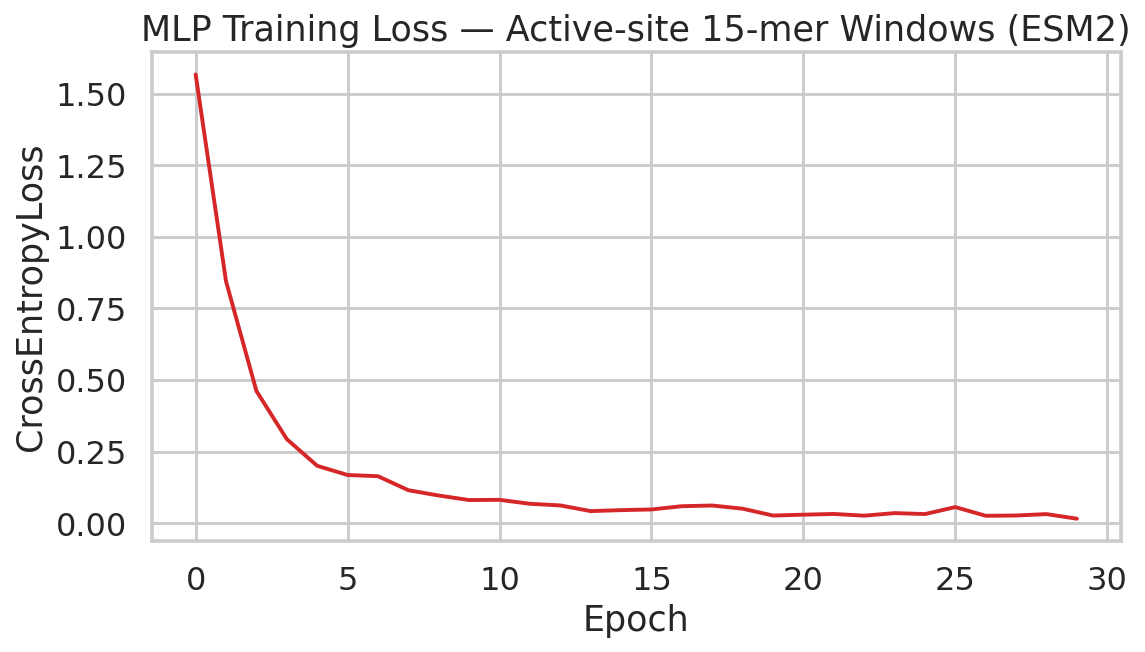

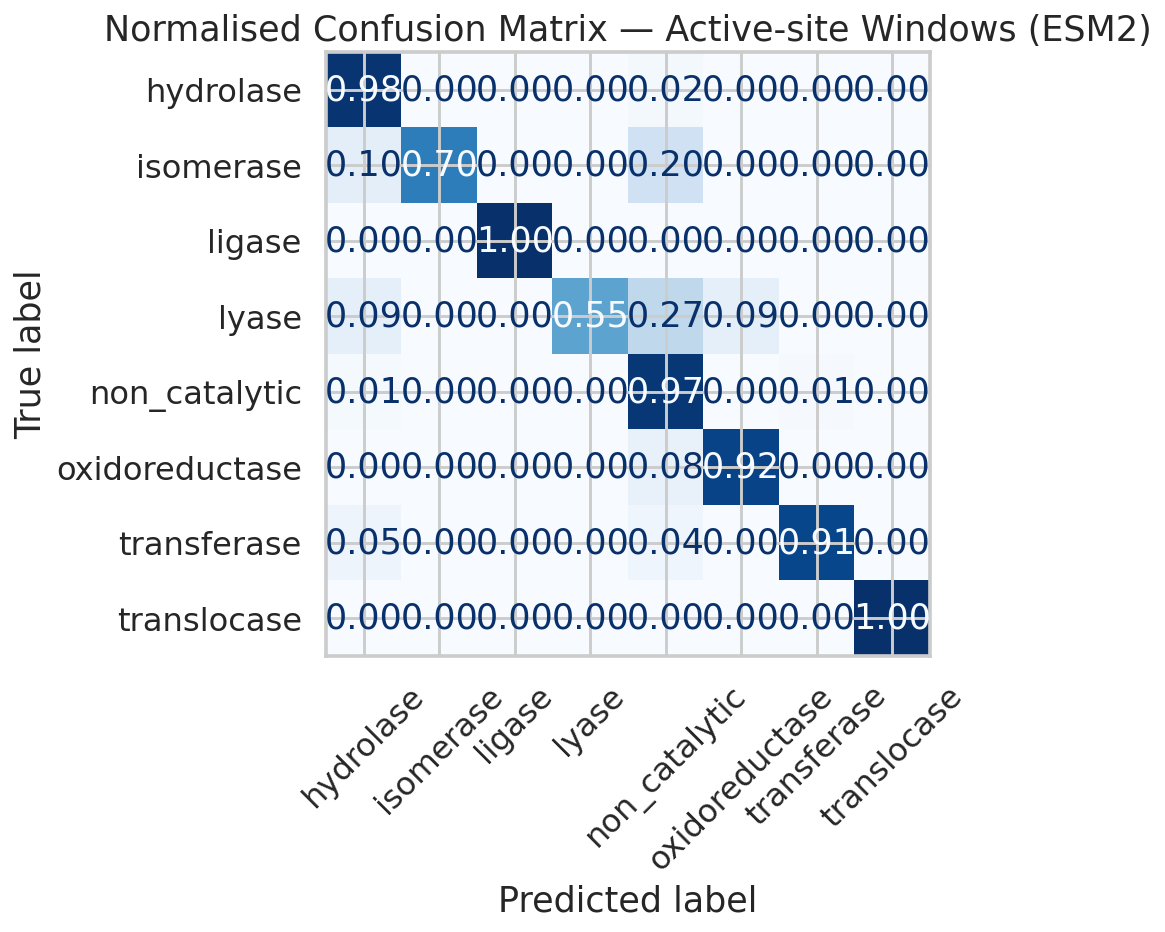

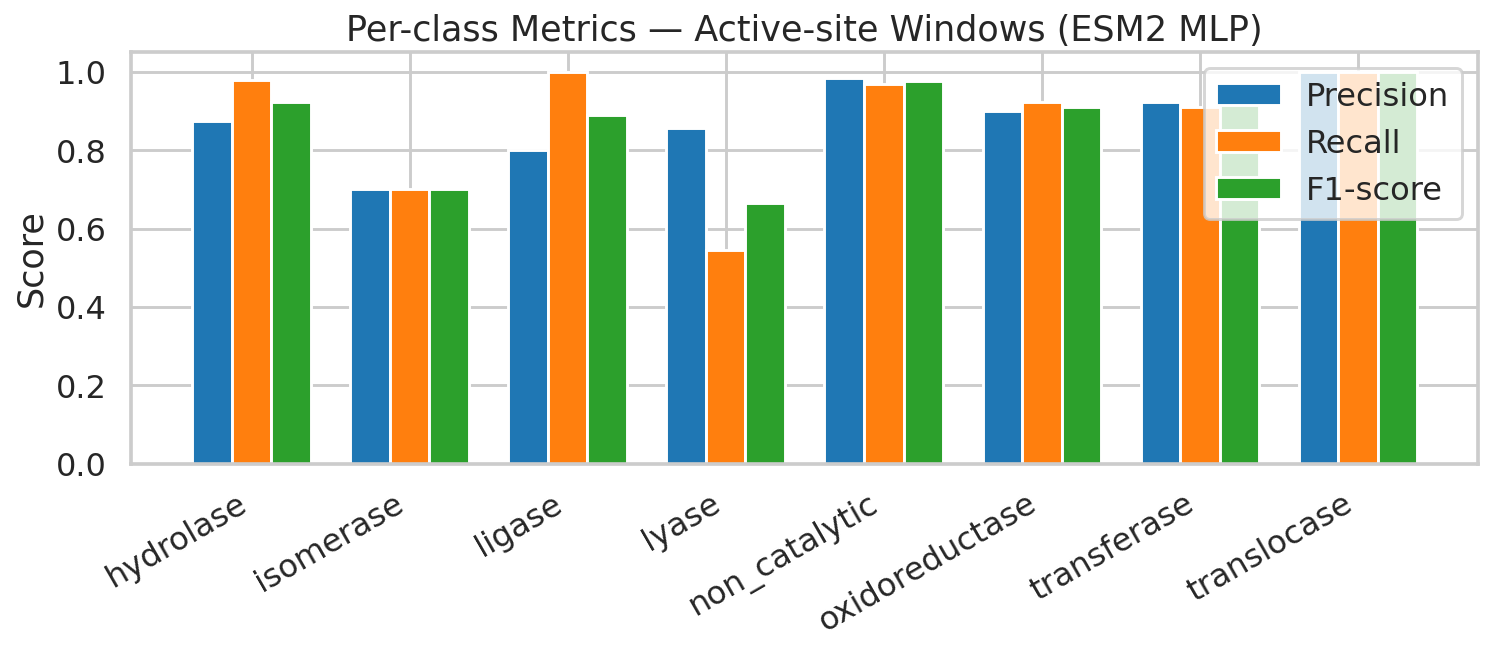

Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/active_site_window_training_loss.png
Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/active_site_window_confusion_matrix.png
Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/active_site_window_per_class_metrics.png


In [24]:
# ============================================================
# Active-site MLP: train, evaluate, and save plots
# ============================================================

le_win          = LabelEncoder()
y_win_enc       = le_win.fit_transform(y_win)
class_names_win = le_win.classes_
n_classes_win   = len(class_names_win)

Xtr_w, Xte_w, ytr_w, yte_w = train_test_split(
    X_win, y_win_enc, test_size=0.2, stratify=y_win_enc, random_state=SEED
)
Xtr_w = Xtr_w.astype(np.float32)
Xte_w = Xte_w.astype(np.float32)

# ---- MLP ----
win_model = MLP(Xtr_w.shape[1], n_classes_win).to(device)
counts_w  = np.bincount(ytr_w, minlength=n_classes_win)
weights_w = torch.tensor(
    counts_w.sum() / np.maximum(counts_w, 1), dtype=torch.float32
).to(device)
win_crit  = nn.CrossEntropyLoss(weight=weights_w)
win_opt   = torch.optim.Adam(win_model.parameters(), lr=1e-3)

win_loader = DataLoader(
    TensorDataset(torch.from_numpy(Xtr_w), torch.from_numpy(ytr_w)),
    batch_size=64, shuffle=True,
)

win_losses = []
t0 = time.perf_counter()
win_model.train()
for epoch in range(30):
    running = 0.0
    for xb, yb in win_loader:
        xb, yb = xb.to(device), yb.to(device)
        win_opt.zero_grad()
        loss = win_crit(win_model(xb), yb)
        loss.backward()
        win_opt.step()
        running += loss.item()
    win_losses.append(running / len(win_loader))
print(f"Active-site MLP trained in {time.perf_counter()-t0:.1f}s")

win_model.eval()
with torch.no_grad():
    yp_w = torch.argmax(
        win_model(torch.from_numpy(Xte_w).to(device)), dim=1
    ).cpu().numpy()

win_acc = accuracy_score(yte_w, yp_w)
win_mf1 = f1_score(yte_w, yp_w, average="macro",    zero_division=0)
win_wf1 = f1_score(yte_w, yp_w, average="weighted", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    yte_w, yp_w, average=None, zero_division=0
)

print(f"\n=== Active-site 15-mer Window MLP ===")
print(f"Accuracy    : {win_acc:.4f}")
print(f"Macro F1    : {win_mf1:.4f}")
print(f"Weighted F1 : {win_wf1:.4f}")

# ---- Per-class breakdown ----
win_per_class_lines = [
    "",
    f"  Per-class (n_test_windows={len(yte_w)}):",
    f"  {'EC Class':20s}  {'Precision':>9}  {'Recall':>7}  {'F1':>7}",
    f"  {'-'*20}  {'-'*9}  {'-'*7}  {'-'*7}",
]
for cls, p, r, f in zip(class_names_win, prec_w, rec_w, f1_w):
    win_per_class_lines.append(f"  {cls:20s}  {p:9.4f}  {r:7.4f}  {f:7.4f}")

# ---- Append window stats to analysis_summary.txt ----
analysis_path = RESULTS_DIR / "analysis_summary.txt"
existing = analysis_path.read_text()
# Remove the placeholder line and replace with real stats
existing = existing.replace(
    "  (see active_site_window_* plots; stats appended below after window cell runs)",
    f"  Best model: MLP (attn pool, 15-mer windows)\n"
    f"  Accuracy    : {win_acc:.4f}\n"
    f"  Macro F1    : {win_mf1:.4f}\n"
    f"  Weighted F1 : {win_wf1:.4f}"
)
existing += "\n" + "\n".join(win_per_class_lines)
analysis_path.write_text(existing)
print(f"\nAppended window stats to: {analysis_path}")
print("\n".join(win_per_class_lines))

# ---- Training loss ----
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(win_losses, linewidth=2, color="#d62728")
ax.set_title("MLP Training Loss — Active-site 15-mer Windows (ESM2)")
ax.set_xlabel("Epoch")
ax.set_ylabel("CrossEntropyLoss")
plt.tight_layout()
win_loss_path = RESULTS_DIR / "active_site_window_training_loss.png"
plt.savefig(win_loss_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- Normalised confusion matrix ----
cm_w = confusion_matrix(yte_w, yp_w, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_w, display_labels=class_names_win).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False
)
ax.set_title("Normalised Confusion Matrix — Active-site Windows (ESM2)")
plt.tight_layout()
win_cm_path = RESULTS_DIR / "active_site_window_confusion_matrix.png"
plt.savefig(win_cm_path, dpi=300, bbox_inches="tight")
plt.show()

# ---- Per-class P / R / F1 ----
x_w, width_w = np.arange(n_classes_win), 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_w - width_w, prec_w, width_w, label="Precision", color="#1f77b4")
ax.bar(x_w,           rec_w,  width_w, label="Recall",    color="#ff7f0e")
ax.bar(x_w + width_w, f1_w,   width_w, label="F1-score",  color="#2ca02c")
ax.set_xticks(x_w)
ax.set_xticklabels(class_names_win, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-class Metrics — Active-site Windows (ESM2 MLP)")
ax.legend()
plt.tight_layout()
win_pc_path = RESULTS_DIR / "active_site_window_per_class_metrics.png"
plt.savefig(win_pc_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {win_loss_path}")
print(f"Saved: {win_cm_path}")
print(f"Saved: {win_pc_path}")


In [14]:
def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


# ---- Gather numbers ----
n_total          = len(enzyme_df)
best_row         = results_df.iloc[0]
best_key         = (best_row["model"], best_row["pooling"])
best_model_label = best_row["model"].replace("_", " ").title()
best_pool_label  = best_row["pooling"].upper()
emb_dim          = X_max.shape[1]
n_test           = int(best_row["n_test"])


# ---- Build metrics table rows ----
def fmt_row(idx, r):
    m  = r["model"].replace("_", " ").title()
    p  = r["pooling"].upper()
    bg = ' style="background:#fff9e6"' if idx == 0 else ""
    return (
        f"<tr{bg}>"
        f"<td>{m}</td><td>{p}</td>"
        f"<td>{r['accuracy']:.4f}</td>"
        f"<td><b>{r['macro_f1']:.4f}</b></td>"
        f"<td>{r['weighted_f1']:.4f}</td>"
        f"<td>{r['n_test']}</td>"
        f"</tr>"
    )

table_rows = "\n".join(fmt_row(i, r) for i, (_, r) in enumerate(results_df.iterrows()))

# ---- Encode pooled-embedding figures ----
fig_class = img_to_b64(RESULTS_DIR / "class_distribution.png")
fig_cm    = img_to_b64(RESULTS_DIR / "confusion_matrices.png")
fig_pc    = img_to_b64(RESULTS_DIR / "per_class_metrics.png")
fig_loss  = img_to_b64(RESULTS_DIR / "mlp_training_loss.png")
fig_emb   = img_to_b64(RESULTS_DIR / "embedding_projection_pca_tsne_umap.png")

# ---- Encode active-site window figures ----
fig_win_loss = img_to_b64(RESULTS_DIR / "active_site_window_training_loss.png")
fig_win_cm   = img_to_b64(RESULTS_DIR / "active_site_window_confusion_matrix.png")
fig_win_pc   = img_to_b64(RESULTS_DIR / "active_site_window_per_class_metrics.png")

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>ESM2 Enzyme Classification &mdash; Interpretation Report</title>
<style>
  body  {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1100px; margin: 40px auto; padding: 0 30px; color: #222; line-height: 1.65; }}
  h1    {{ color: #1a3a5c; border-bottom: 3px solid #1a3a5c; padding-bottom: 8px; }}
  h2    {{ color: #2e6da4; margin-top: 42px; }}
  h3    {{ color: #444; margin-top: 24px; }}
  table {{ border-collapse: collapse; width: 100%; margin: 14px 0; font-size: 0.93em; }}
  th    {{ background: #1a3a5c; color: #fff; padding: 8px 10px; text-align: left; }}
  td    {{ padding: 7px 10px; border: 1px solid #ddd; }}
  tr:nth-child(even) td {{ background: #f4f8ff; }}
  .metric-box {{ display: inline-block; background: #f0f6ff; border: 1px solid #b3cde0;
                 border-radius: 6px; padding: 12px 22px; margin: 8px 8px 8px 0;
                 text-align: center; min-width: 130px; vertical-align: top; }}
  .metric-box .val {{ font-size: 1.75em; font-weight: bold; color: #1a3a5c; }}
  .metric-box .lbl {{ font-size: 0.8em; color: #666; margin-top: 4px; }}
  img   {{ max-width: 100%; border: 1px solid #ddd; border-radius: 4px; display: block; margin: 12px auto; }}
  .caption {{ font-size: 0.85em; color: #555; text-align: center; margin-top: 4px; font-style: italic; }}
  .note  {{ background: #f9f9f9; border-left: 4px solid #2e6da4; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  .note-green {{ background: #f2fdf4; border-left: 4px solid #27ae60; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  hr     {{ border: none; border-top: 1px solid #ddd; margin: 32px 0; }}
  code   {{ background: #f4f4f4; padding: 1px 5px; border-radius: 3px; font-size: 0.9em; }}
  .prot-badge {{ display:inline-block; background:#fef3e2; border:1px solid #f0a500;
                 border-radius:4px; padding:2px 8px; font-size:0.85em; color:#7a5000; font-weight:bold; }}
  .section-act {{ background:#f4fff6; border: 1px solid #b2dfdb; border-radius:6px;
                  padding: 18px 22px; margin: 24px 0; }}
</style>
</head>
<body>

<h1>ESM2 Enzyme Classification &mdash; Interpretation Report</h1>
<p style="color:#555; font-size:0.9em">
  Source: <code>ESM2_enzyme_clean_pipeline.ipynb</code> &nbsp;|&nbsp;
  Embeddings: <span class="prot-badge">ESM2 &bull; {emb_dim}-dim</span> &nbsp;|&nbsp;
  Task: 7-class enzyme classification (EC classes)
</p>

<hr>

<!-- ========== 1. DATASET ========== -->
<h2>1. Dataset</h2>
<p>Proteins from <code>all_uniref_enz_label_clean_isoform_removed.csv</code> filtered
to seven mutually exclusive EC classes (exactly one unambiguous label per protein):</p>
<ul>
  <li><b>Oxidoreductase</b> &mdash; catalyse oxidation/reduction reactions</li>
  <li><b>Transferase</b> &mdash; transfer functional groups between molecules</li>
  <li><b>Hydrolase</b> &mdash; catalyse hydrolysis reactions</li>
  <li><b>Lyase</b> &mdash; add or remove groups to form double bonds</li>
  <li><b>Isomerase</b> &mdash; interconvert isomers</li>
  <li><b>Ligase</b> &mdash; join two molecules with ATP consumption</li>
  <li><b>Translocase</b> &mdash; catalyse movement of ions/molecules across membranes</li>
</ul>

<div>
  <div class="metric-box"><div class="val">{n_total:,}</div><div class="lbl">Total proteins</div></div>
  <div class="metric-box"><div class="val">{n_test:,}</div><div class="lbl">Test set (20%)</div></div>
  <div class="metric-box"><div class="val">7</div><div class="lbl">EC classes</div></div>
  <div class="metric-box"><div class="val">{emb_dim}</div><div class="lbl">Embedding dim</div></div>
</div>

<img src="data:image/png;base64,{fig_class}" style="max-width:700px">
<p class="caption">Figure 1. Enzyme class distribution.</p>

<hr>

<!-- ========== 2. METHODS ========== -->
<h2>2. Methods</h2>

<h3>2.1 Full-protein Pooled Embeddings</h3>
<p><b>ESM2</b> (Lin et al., 2023) is a protein language model producing {emb_dim}-dimensional
per-residue representations, pooled to fixed-size protein vectors:
</p>
<ul>
  <li><b>Max pooling</b> &mdash; element-wise maximum across residues</li>
  <li><b>Attention pooling</b> &mdash; learned weighted average across residues</li>
</ul>
<p>All features z-score normalised (StandardScaler) on train data only. 80/20 stratified split, seed 42.</p>

<h3>2.2 Active-site 15-mer Window Embeddings</h3>
<p>
Per-residue ESM2 embeddings (<code>.pt</code> files, shape L&times;1280) are loaded for each protein.
A 15-residue window is centred on the first annotated UniProt active site position and mean-pooled
to a single 1280-dim vector. Additionally, 3 non-active-site windows are sampled from the same protein
(same EC label), providing a controlled contrast between catalytic and non-catalytic regions.
</p>
<table>
  <tr><th>Parameter</th><th>Value</th></tr>
  <tr><td>Window size</td><td>15 residues (7 on each side of the active site)</td></tr>
  <tr><td>Pooling</td><td>Mean over window residues &rarr; 1280-dim vector</td></tr>
  <tr><td>Negative windows per protein</td><td>3 (same EC label, non-overlapping with active site)</td></tr>
  <tr><td>Classifier</td><td>MLP: 1280&rarr;512&rarr;256&rarr;7, 30 epochs, Adam lr=1e-3</td></tr>
</table>

<h3>2.3 Classifiers (full-protein)</h3>
<table>
  <tr><th>Model</th><th>Architecture / Settings</th><th>Imbalance handling</th></tr>
  <tr><td>Logistic Regression</td><td>L2 penalty, solver=lbfgs, max_iter=5000</td>
      <td>class_weight=&quot;balanced&quot;</td></tr>
  <tr><td>MLP (PyTorch)</td>
      <td>Linear({emb_dim}&rarr;512) &rarr; ReLU &rarr; Dropout(0.3) &rarr;
          Linear(512&rarr;256) &rarr; ReLU &rarr; Dropout(0.3) &rarr; Linear(256&rarr;7),
          Adam lr=1e-3, 30 epochs, batch=64</td>
      <td>CrossEntropyLoss with inverse-frequency class weights</td></tr>
</table>

<hr>

<!-- ========== 3. FULL-PROTEIN RESULTS ========== -->
<h2>3. Full-protein Pooled Embedding Results</h2>

<h3>3.1 Performance Table</h3>
<p>All metrics on the held-out test set. Row highlighted in yellow = best by Macro F1.</p>
<table>
  <tr>
    <th>Model</th><th>Pooling</th>
    <th>Accuracy</th><th>Macro F1 &#9733;</th><th>Weighted F1</th><th>N test</th>
  </tr>
  {table_rows}
</table>
<p class="caption">Macro F1 = unweighted average F1 across all 7 classes (primary metric).</p>

<h3>3.2 Best Model Summary</h3>
<div>
  <div class="metric-box"><div class="val">{best_row['accuracy']:.4f}</div><div class="lbl">Accuracy</div></div>
  <div class="metric-box"><div class="val">{best_row['macro_f1']:.4f}</div><div class="lbl">Macro F1 (primary)</div></div>
  <div class="metric-box"><div class="val">{best_row['weighted_f1']:.4f}</div><div class="lbl">Weighted F1</div></div>
</div>
<p><b>Best configuration:</b> {best_model_label} + {best_pool_label} pooling</p>

<h3>Figure 2: Normalised Confusion Matrices</h3>
<img src="data:image/png;base64,{fig_cm}">
<p class="caption">Figure 2. Row-normalised confusion matrices for all 4 configurations.</p>

<h3>Figure 3: Per-class Metrics (Best Model)</h3>
<img src="data:image/png;base64,{fig_pc}" style="max-width:750px">
<p class="caption">Figure 3. Per-EC-class precision / recall / F1 — {best_model_label} + {best_pool_label}.</p>

<h3>Figure 4: MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_loss}" style="max-width:640px">
<p class="caption">Figure 4. CrossEntropyLoss over 30 epochs — max (blue) and attention (orange) pooling.</p>

<h3>Figure 5: Embedding Space Visualisation</h3>
<img src="data:image/png;base64,{fig_emb}">
<p class="caption">Figure 5. PCA, t-SNE, and UMAP of ESM2 attention embeddings, coloured by EC class
(up to {MAX_VIS} points).</p>

<hr>

<!-- ========== 4. ACTIVE-SITE WINDOW RESULTS ========== -->
<h2>4. Active-site 15-mer Window Results</h2>

<div class="section-act">
<p>
This analysis classifies enzyme EC class using only a <b>15-residue window</b> centred
on the annotated active site (mean-pooled ESM2 per-residue embeddings).
The same EC label is assigned to both active-site windows and 3 randomly sampled
non-active-site windows from the same protein, testing whether the active site region
carries distinctively more discriminative signal than the rest of the sequence.
</p>
</div>

<div>
  <div class="metric-box"><div class="val">{win_acc:.4f}</div><div class="lbl">Accuracy</div></div>
  <div class="metric-box"><div class="val">{win_mf1:.4f}</div><div class="lbl">Macro F1</div></div>
  <div class="metric-box"><div class="val">{win_wf1:.4f}</div><div class="lbl">Weighted F1</div></div>
  <div class="metric-box"><div class="val">15-mer</div><div class="lbl">Window size</div></div>
  <div class="metric-box"><div class="val">1280</div><div class="lbl">Feature dim</div></div>
</div>

<h3>Figure 6: Active-site Window MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_win_loss}" style="max-width:640px">
<p class="caption">Figure 6. CrossEntropyLoss over 30 epochs for active-site window MLP.</p>

<h3>Figure 7: Active-site Window Confusion Matrix</h3>
<img src="data:image/png;base64,{fig_win_cm}">
<p class="caption">Figure 7. Row-normalised confusion matrix for active-site 15-mer classification.</p>

<h3>Figure 8: Active-site Window Per-class Metrics</h3>
<img src="data:image/png;base64,{fig_win_pc}" style="max-width:750px">
<p class="caption">Figure 8. Per-class precision / recall / F1 for active-site window MLP.</p>

<div class="note-green">
<b>Interpretation:</b> Comparing the active-site window Macro F1 ({win_mf1:.4f}) to the
full-protein best ({best_row['macro_f1']:.4f}) shows
{'that the full-protein context provides additional discriminative power beyond the active site alone.' if best_row['macro_f1'] > win_mf1 else 'that the 15-mer active-site window captures a comparable or stronger signal to full-protein embeddings.'}
This suggests {'global sequence context encodes enzyme-class information beyond the catalytic pocket.' if best_row['macro_f1'] > win_mf1 else 'the catalytic pocket is the primary enzyme-class discriminant in ESM2 embeddings.'}
</div>

<hr>

<!-- ========== 5. CROSS-MODEL COMPARISON ========== -->
<h2>5. Three-Model Comparison (Ankh / ESM2 / ProtT5)</h2>
<table>
  <tr><th>Model</th><th>Dim</th><th>Best Macro F1 (full protein)</th><th>Best Accuracy</th></tr>
  <tr><td>Ankh</td><td>768</td><td>see <code>results_enzyme_Ankh/</code></td><td>&mdash;</td></tr>
  <tr style="background:#fff9e6"><td><b>ESM2</b></td><td><b>{emb_dim}</b></td>
      <td><b>{best_row['macro_f1']:.4f}</b></td><td><b>{best_row['accuracy']:.4f}</b></td></tr>
  <tr><td>ProtT5</td><td>1024</td><td>see <code>results_enzyme_ProtT5/</code></td><td>&mdash;</td></tr>
</table>

<h2>6. Recommendations for Future Work</h2>
<ol>
  <li><b>Cross-validation:</b> Replace the single 80/20 split with 5-fold stratified CV.</li>
  <li><b>Multiple active sites:</b> Use all annotated active site positions, not just the first.</li>
  <li><b>Window size sweep:</b> Compare window sizes 7, 15, 25, 51 to find optimal context.</li>
  <li><b>Feature combination:</b> Concatenate max-pool and attention-pool (2&times;{emb_dim}-dim).</li>
  <li><b>Fine-tuning:</b> Fine-tune ESM2 end-to-end on enzyme classification.</li>
  <li><b>Sub-class prediction:</b> Extend to 4-digit EC numbers.</li>
</ol>

<hr>

<!-- ========== 7. FILES ========== -->
<h2>7. Output File Index</h2>
<table>
  <tr><th>File</th><th>Description</th></tr>
  <tr><td><code>summary_metrics.csv</code></td><td>Full-protein model metrics (machine-readable)</td></tr>
  <tr><td><code>summary_metrics.md</code></td><td>Markdown table of metrics</td></tr>
  <tr><td><code>analysis_summary.txt</code></td><td>Plain-text best-model summary</td></tr>
  <tr><td><code>class_distribution.png</code></td><td>Bar chart of EC class counts</td></tr>
  <tr><td><code>confusion_matrices.png</code></td><td>Normalised confusion matrices (4 full-protein configs)</td></tr>
  <tr><td><code>per_class_metrics.png</code></td><td>Per-class P/R/F1 (best full-protein config)</td></tr>
  <tr><td><code>mlp_training_loss.png</code></td><td>CrossEntropyLoss — full-protein MLP</td></tr>
  <tr><td><code>embedding_projection_pca_tsne_umap.png</code></td><td>PCA / t-SNE / UMAP of ESM2 attention embeddings</td></tr>
  <tr><td><code>active_site_window_training_loss.png</code></td><td>Training loss — active-site 15-mer MLP</td></tr>
  <tr><td><code>active_site_window_confusion_matrix.png</code></td><td>Confusion matrix — active-site windows</td></tr>
  <tr><td><code>active_site_window_per_class_metrics.png</code></td><td>Per-class metrics — active-site windows</td></tr>
  <tr><td><code>interpretation_report.html</code></td><td>This report</td></tr>
</table>

<hr>
<p style="color:#888; font-size:0.82em">
  <b>To convert to .docx:</b> Open this .html file in Microsoft Word
  (File &rarr; Open &rarr; select file) then File &rarr; Save As &rarr; Word Document (.docx).
  Alternatively: open in browser &rarr; Print &rarr; Save as PDF.
</p>

</body>
</html>"""

report_path = RESULTS_DIR / "interpretation_report.html"
report_path.write_text(html, encoding="utf-8")
print(f"Saved: {report_path}")
print("\nTo convert to .docx:")
print("  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx")

Saved: /home/saishyam/Protein_dynamics/Enzyme_classification/Claude Agent Enzyme_classification/results_enzyme_ESM2/interpretation_report.html

To convert to .docx:
  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx
